# Analyze Summer Trends in the CMIP6 Data

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
import pwlf #piecewise linear fits

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'statsmodels'

## Build and write out the full data set as single file

In [ ]:
%%time

# start with one year and add a coordinate for the year
year = 1990
input_path = '../../../Data/CMIP6/GFDL-ESM4/Summers/'+str(year)+'_GFDL-ESM4_r1i1p1f1_summer_stats.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1991,2024,1)

for year in input_years:
    input_path = '../../../Data/CMIP6/GFDL-ESM4/Summers/'+str(year)+'_GFDL-ESM4_r1i1p1f1_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

In [4]:
ds_base

<xarray.Dataset> Size: 127MB
Dimensions:       (lat: 180, lon: 288, time: 34)
Coordinates:
  * lat           (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon           (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
  * time          (time) datetime64[us] 272B 1990-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 14MB 148.0 148.0 ... 156.0 156.0
    SummerEnd     (time, lat, lon) float64 14MB 212.0 212.0 ... 257.0 257.0
    SummerTmax    (time, lat, lon) float64 14MB 177.0 177.0 ... 218.0 218.0
    SummerHeat    (time, lat, lon) float64 14MB 303.5 303.4 ... 169.2 168.9
    SummerLength  (time, lat, lon) float64 14MB 65.0 65.0 65.0 ... 102.0 102.0
    SummerRMSE    (time, lat, lon) float64 14MB 5.675 5.668 5.661 ... 4.424 4.42
    SummerR2      (time, lat, lon) float64 14MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanT   (time, lat, lon) float64 14MB 240.2 240.2 ... 272.3 272.3
    SummerMeanHS  (time, lat, lon) float64 14MB 5.519 5.517 ... 1.839 1.836

In [5]:
# re-add attributes which get lost on merge apparently
ds_base.SummerStart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
ds_base.SummerStart.attrs["units"] = "Day of year"

ds_base.SummerEnd.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
ds_base.SummerEnd.attrs["units"] = "Day of year"

ds_base.SummerTmax.attrs["long_name"] = "Day of max mean temp during summer for the year"
ds_base.SummerTmax.attrs["units"] = "Day of year"

ds_base.SummerHeat.attrs["long_name"] = "Accumulated heat during summer for the year"
ds_base.SummerHeat.attrs["units"] = "Degree-Days"

ds_base.SummerLength.attrs["long_name"] = "Duration of summer for the year"
ds_base.SummerLength.attrs["units"] = "Days"

ds_base.SummerRMSE.attrs["long_name"] = "Root mean squared error of polynomial fit"
ds_base.SummerRMSE.attrs["units"] = "Degrees [K]"

ds_base.SummerR2.attrs["long_name"] = "Coefficient of determination (R-squared) of Fourier fit [NOT USED]"
ds_base.SummerR2.attrs["units"] = "Variance explained"

ds_base.SummerMeanT.attrs["long_name"] = "Mean temperature during the summer period"
ds_base.SummerMeanT.attrs["units"] = "Degrees [K]"

ds_base.SummerMeanHS.attrs["long_name"] = "Mean HS temperature during the summer period"
ds_base.SummerMeanHS.attrs["units"] = "Degrees [K]"

ds_base

<xarray.Dataset> Size: 127MB
Dimensions:       (lat: 180, lon: 288, time: 34)
Coordinates:
  * lat           (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon           (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
  * time          (time) datetime64[us] 272B 1990-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 14MB 148.0 148.0 ... 156.0 156.0
    SummerEnd     (time, lat, lon) float64 14MB 212.0 212.0 ... 257.0 257.0
    SummerTmax    (time, lat, lon) float64 14MB 177.0 177.0 ... 218.0 218.0
    SummerHeat    (time, lat, lon) float64 14MB 303.5 303.4 ... 169.2 168.9
    SummerLength  (time, lat, lon) float64 14MB 65.0 65.0 65.0 ... 102.0 102.0
    SummerRMSE    (time, lat, lon) float64 14MB 5.675 5.668 5.661 ... 4.424 4.42
    SummerR2      (time, lat, lon) float64 14MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanT   (time, lat, lon) float64 14MB 240.2 240.2 ... 272.3 272.3
    SummerMeanHS  (time, lat, lon) float64 14MB 5.519 5.517 ... 1.839 1.836

## Write out dataset

In [9]:
# write out complete dataset 
output_path = '../../../Data/CMIP6/GFDL-ESM4/Summers/1990-2023_ALL_summer_stats.nc'
ds_base.to_netcdf(output_path)



## *** Jump here now - reload dataset

In [10]:
ds = xr.open_dataset('../../../Data/CMIP6/GFDL-ESM4/Summers/1990-2023_ALL_summer_stats.nc')
ds

<xarray.Dataset> Size: 127MB
Dimensions:       (time: 34, lat: 180, lon: 288)
Coordinates:
  * time          (time) datetime64[ns] 272B 1990-01-01 ... 2023-01-01
  * lat           (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon           (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
Data variables:
    SummerStart   (time, lat, lon) float64 14MB ...
    SummerEnd     (time, lat, lon) float64 14MB ...
    SummerTmax    (time, lat, lon) float64 14MB ...
    SummerHeat    (time, lat, lon) float64 14MB ...
    SummerLength  (time, lat, lon) float64 14MB ...
    SummerRMSE    (time, lat, lon) float64 14MB ...
    SummerR2      (time, lat, lon) float64 14MB ...
    SummerMeanT   (time, lat, lon) float64 14MB ...
    SummerMeanHS  (time, lat, lon) float64 14MB ...

In [12]:
# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"

In [13]:
# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

### Weighted mean metrics for NH and SH

In [14]:
%%time

nh_full = ds.where((ds.lat >= nh_min) & (ds.lat <= nh_max)).weighted(weights).mean(dim=['lat','lon'])
sh_full = ds.where((ds.lat >= sh_max) & (ds.lat <= sh_min)).weighted(weights).mean(dim=['lat','lon'])

CPU times: user 133 ms, sys: 149 ms, total: 282 ms
Wall time: 367 ms


### Set plot vars

In [16]:
plot_vars = list(ds.data_vars)
remove_me = {'SummerTmax','SummerMeanHS','SummerRMSE','SummerR2'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['SummerStart', 'SummerEnd', 'SummerHeat', 'SummerLength', 'SummerMeanT']

In [17]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20

sns.set_theme(style="darkgrid")

NameError: name 'sns' is not defined

### Reformatted without slopes for paper and only 1990-2023

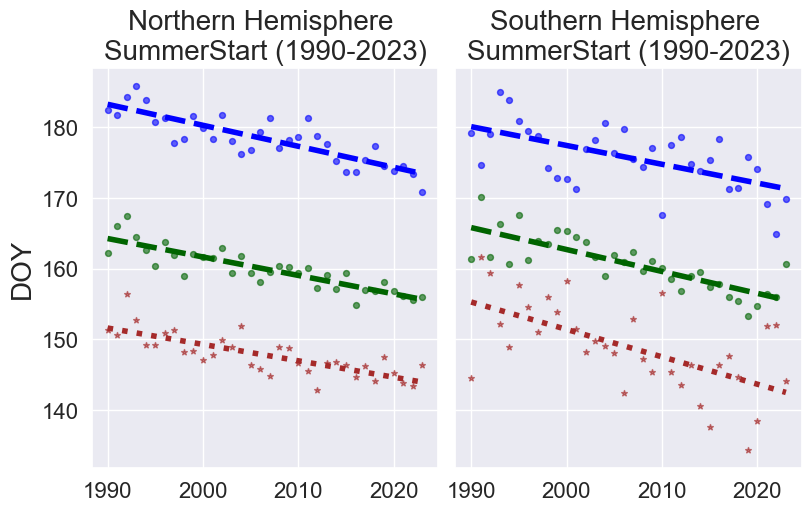

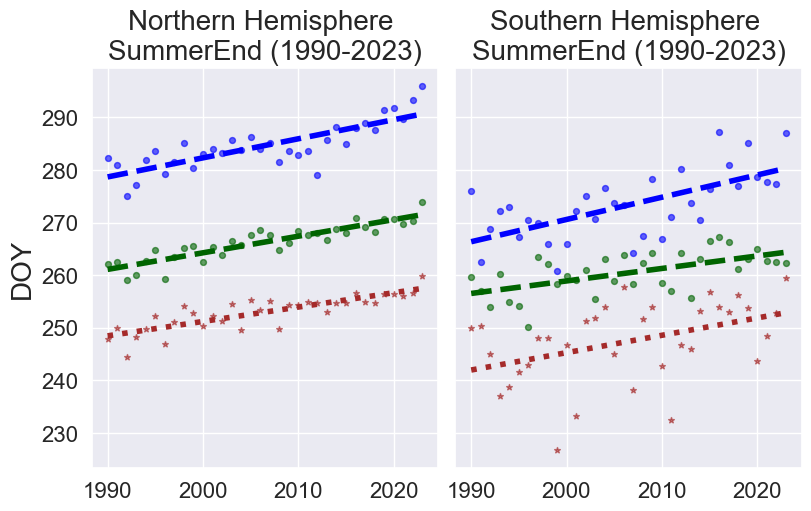

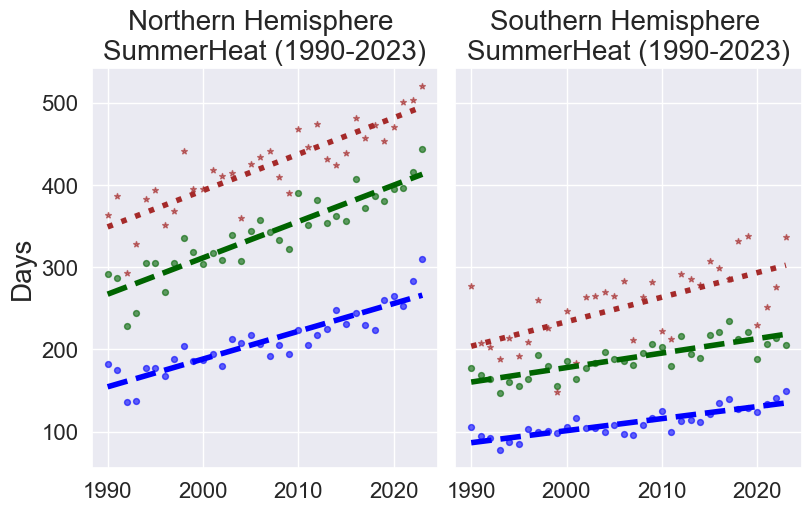

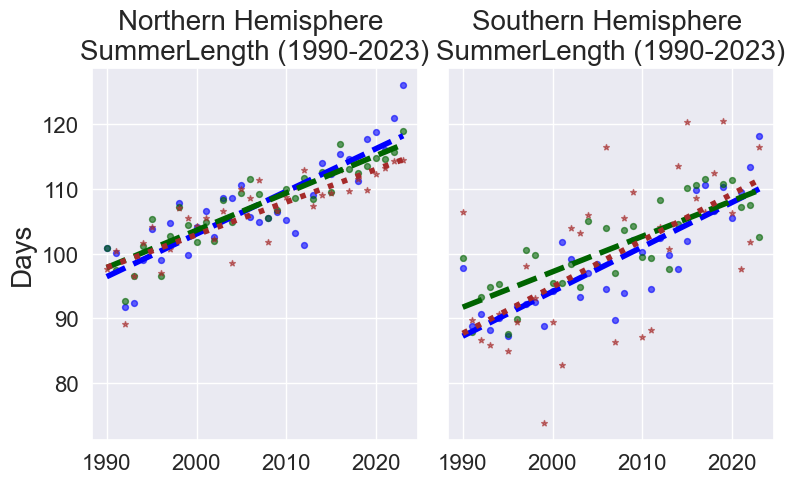

CPU times: user 825 ms, sys: 109 ms, total: 934 ms
Wall time: 1.04 s


In [118]:
%%time

# takes XX sec

# loop through all plot variables
for i,v in enumerate(plot_vars):

    # create blank fig
    fig = plt.figure(figsize = (8,5), layout='constrained')

    # Analysis time period NH
    ax3 = fig.add_subplot(1,2,1)

    # linear fits for slope
    x = nh_full.time.dt.year.values
    y = nh_full[v].values
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],2)
    slope_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax3.scatter(x, y, label="NH GFDL-ESM4", marker='*', facecolors='black', edgecolors='black', s=s, alpha=alpha)
    ax3.plot(x, poly(x), linestyle="dotted", linewidth=lw, color='black',
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    ax3.set_title("Northern Hemisphere \n" + v + " (1990-2023)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax3.get_yticks())[-3]+8
    # ann_x = np.mean(ax3.get_xticks())-5
    # # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax3.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    if i < 2:
        ylabel = 'DOY'
    elif i == 3:
        ylabel = '$^\circ$C$\cdot$Days'
    elif i == 4:
        ylabel = 'Days'
    else:
        ylabel = '$^\circ$C$'
    ax3.set_ylabel(ylabel, fontsize=fs)
    ax3.legend(loc='best')

    
    # Analysis time period SH
    ax4 = fig.add_subplot(1,2,2, sharey=ax3)

    # linear fits for slope
    x = sh_full.time.dt.year.values
    y = sh_full[v].values
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],2)
    slope_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax4.scatter(x, y, label="SH GFDL-ESM4", marker='*', facecolors='black', edgecolors='black', s=s, alpha=alpha)
    ax4.plot(x, poly(x), linestyle="dotted", linewidth=lw, color='black',
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    ax4.set_title("Southern Hemisphere \n" + v + " (1990-2023)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax4.get_yticks())[-3]+8
    # ann_x = np.mean(ax4.get_xticks())-5
    #     # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax4.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    ax4.legend(loc='best')


plt.tight_layout()
plt.show()